In [9]:
import torch
import ultralytics
import kagglehub

print("torch:", torch.__version__)
print("MPS is here", torch.backends.mps.is_available())

torch: 2.13.0
MPS is here True


In [10]:
from pathlib import Path

path = kagglehub.dataset_download("akinduhiman/urban-issues-dataset")
root = Path(path)
print("Dataset path:", root)

Dataset path: /Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19


In [11]:
potholes = root / "Potholes and RoadCracks"
print("Inside Potholes and RoadCracks:")
for p in sorted(potholes.iterdir()):
    print(" ", p.name)

Inside Potholes and RoadCracks:
  Potholes and RoadCracks


In [12]:
inner  = potholes / "Potholes and RoadCracks"
print("Inside Potholes and RoadCracks:")
for p in sorted(inner.iterdir()):
    print(" ", p.name)



Inside Potholes and RoadCracks:
  test
  train
  valid


In [13]:
innermain  = inner / "train"
print("Inside train:")
for p in sorted(innermain.iterdir()):
    print(" ", p.name)



Inside train:
  images
  labels
  labels.cache


In [14]:
images  = innermain / "images"
print("Inside images:")
imgs = sorted(images.iterdir())
print("number of images:", len(imgs))
for p in imgs[:5]:
    print(" ", p.name)


labels  = innermain / "labels"
print("Inside labels:")
lbls = sorted(labels.iterdir())
print("number of labels:", len(lbls))


Inside images:
number of images: 5667
  1-7-_jpg.rf.cd534274dc43f29782da16048504fad6.jpg
  100_jpg.rf.007bfbb6df4e5d8fcb83ce77f63fb11c.jpg
  100_jpg.rf.3a05a2a537ad06251dc4a5a1ca4bbf8b.jpg
  100_jpg.rf.3caf197d115db938f70442b9cbefbe34.jpg
  100_jpg.rf.5554a3ecfb13f8c6a8c376d968ac3a9e.jpg
Inside labels:
number of labels: 5667


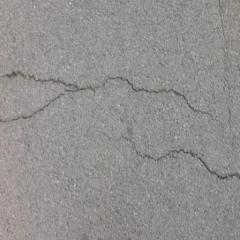

In [15]:
from IPython.display import Image, display
display(Image(imgs[0]))

In [16]:
print((labels / (imgs[0].stem + ".txt")).read_text())


0 0 0.5256614916666666 0.9421107333333333 0.5238763458333333 0.9438962458333333 0.28109291666666664 0 0.27752255833333334 0 0.5256614916666666
0 1 0.5810018791666667 0.5171842958333334 0.5863575166666667 0.5243258083333333 0.7523784083333334 1 0.7470230416666667 1 0.5810018791666667



In [17]:
yaml_path = Path("potholes_data.yaml")

yaml_path.write_text(f"""
path: {inner.resolve()}
train: train/images
val: valid/images
test: test/images
names:
  0: Damaged Road issues
  1: Pothole Issues
""")
print(yaml_path.read_text())
print(yaml_path.resolve())





path: /Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/Potholes and RoadCracks/Potholes and RoadCracks
train: train/images
val: valid/images
test: test/images
names:
  0: Damaged Road issues
  1: Pothole Issues

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/potholes_data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data = str(yaml_path.resolve()),
    epochs = 6,
    imgsz = 640,
    batch = 16,
    device = "mps",
    project = "runs",
    name = "potholesv1",
)

In [ ]:
weights = Path("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv1/weights/best.pt")

print(weights.exists())  # should be True

In [ ]:
from ultralytics import YOLO

model = YOLO(str(weights))

results = model.train(
    data=str(yaml_path.resolve()),
    epochs=40,
    patience=15,
    imgsz=640,
    batch=16,
    device="mps",
    project="runs",
    name="potholesv2",
    save = True,
    plots = True,
    exist_ok = False,
    workers = 8
)

In [ ]:
from ultralytics import YOLO

model = YOLO("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv2/weights/last.pt")
results = model.train(resume=True)

In [19]:
# after HF login / acceptance
hf = YOLO("cazzz307/Pothole-Finetuned-YoloV8")
ours = YOLO(".../potholesv2/weights/best.pt")

hf.predict("test.jpg", conf=0.4, save=True)
ours.predict("test.jpg", conf=0.4, save=True)

FileNotFoundError: 'cazzz307/Pothole-Finetuned-YoloV8' does not exist

In [20]:
from ultralytics import YOLO

model = YOLO("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv2/weights/best.pt")

results = model.train(
    data=str(yaml_path.resolve()),  # same yaml as before
    epochs=40,          # another 40 (or 30)
    patience=20,        # stop if it truly flats out
    imgsz=640,
    batch=16,
    device="mps",
    project="runs",
    name="potholesv3",
    workers=4,
    resume=True
)

WARNING ⚠️ model '/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv2/weights/best.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.112 🚀 Python-3.12.7 torch-2.13.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/nehasaboo/StudioProjects/street_sync/yolomodel/potholes_data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       1/40      4.29G      1.771      1.453      1.567         60        640: 100% ━━━━━━━━━━━━ 355/355 1.0it/s 5:430.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 29.8s0.7ss
                   all       1219       3165      0.548      0.495      0.496       0.22

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       2/40      4.28G      1.843      1.537      1.609          4        640: 100% ━━━━━━━━━━━━ 355/355 1.1it/s 5:380.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 29.8s0.7ss
                   all       1219       3165      0.529      0.437      0.449      0.196

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      38/40      4.28G      1.612       1.11      1.466          9        640: 100% ━━━━━━━━━━━━ 355/355 1.1it/s 5:380.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.2it/s 32.4s0.8ss
                   all       1219       3165      0.663      0.542      0.595      0.277

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

      39/40      4.31G        1.6      1.096      1.461          5        640: 100% ━━━━━━━━━━━━ 355/355 1.0it/s 5:380.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 30.6s0.8ss
                   all       1219       3165      0.645      0.559      0.598       0.28

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

      40/40      4.31G      1.595      1.092      1.453          7        640: 100% ━━━━━━━━━━━━ 355/355 1.1it/s 5:360.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 30.4s0.8ss
                   all       1219       3165      0.663      0.553      0.604      0.282

40 epochs completed in 4.235 hours.
Optimizer stripped from /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/last.pt, 6.2MB
Optimizer stripped from /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/best.pt, 6.2MB

Validating /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/best.pt...
Ultralytics 8.4.112 🚀 Python-3.12.7 torch-2.13.0 MPS (Apple M5)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.5it/s 25.2s

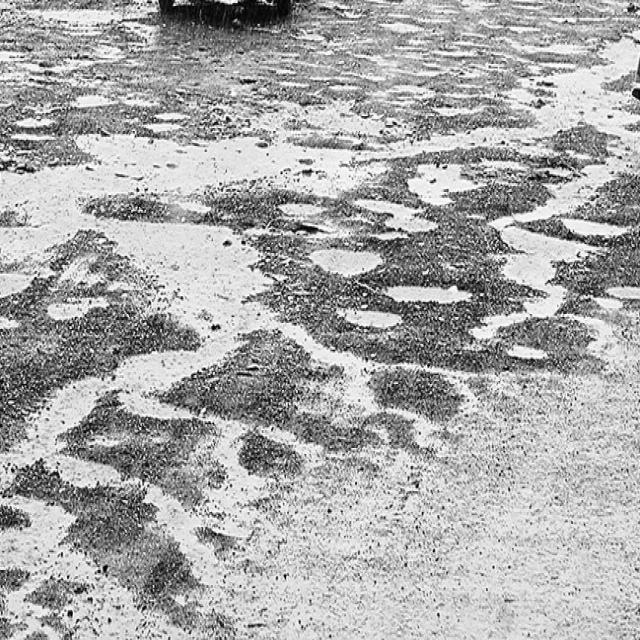


image 1/1 /Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/Potholes and RoadCracks/Potholes and RoadCracks/valid/images/620_jpg.rf.42ebf09baca89a17690154226f728f39.jpg: 640x640 11 Pothole Issuess, 7.8ms
Speed: 1.3ms preprocess, 7.8ms inference, 10.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/nehasaboo/StudioProjects/street_sync/runs/detect/predict-4
detections: 11
Pothole Issues 0.50
Pothole Issues 0.39
Pothole Issues 0.39
Pothole Issues 0.39
Pothole Issues 0.35
Pothole Issues 0.35
Pothole Issues 0.34
Pothole Issues 0.33
Pothole Issues 0.31
Pothole Issues 0.27
Pothole Issues 0.25


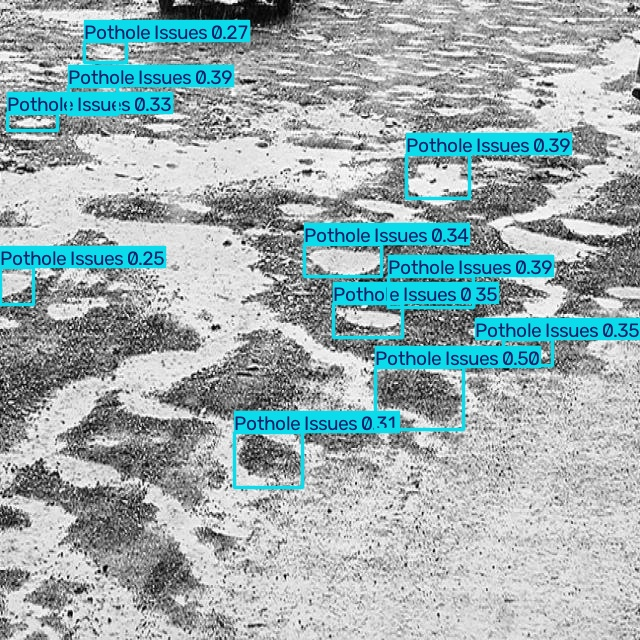

In [24]:
from ultralytics import YOLO
from IPython.display import Image, display
from pathlib import Path

model = YOLO("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/best.pt")

img = "/Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/Potholes and RoadCracks/Potholes and RoadCracks/valid/images/620_jpg.rf.42ebf09baca89a17690154226f728f39.jpg"

# original
display(Image(filename=img, width=500))

results = model.predict(source=img, conf=0.25, device="mps", save=True)

for r in results:
    n = 0 if r.boxes is None else len(r.boxes)
    print("detections:", n)
    if r.boxes is not None:
        for box in r.boxes:
            print(r.names[int(box.cls[0])], f"{float(box.conf[0]):.2f}")

out = Path(results[0].save_dir) / Path(img).name
display(Image(filename=str(out), width=500))

In [25]:
import os
import shutil
from pathlib import Path

SRC = Path("/Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19")
OUT = Path("/Users/nehasaboo/StudioProjects/street_sync/yolomodel/datasets/urban_multi")

# top-level folder name -> nested folder name (same pattern as potholes)
SOURCES = {
    "Potholes and RoadCracks": "Potholes and RoadCracks",
    "Garbage": "Garbage",
    "FallenTrees": "FallenTrees",
    "Graffitti": "Graffitti",
    "DamagedRoadSigns": "DamagedRoadSigns",
    "DamagedElectricalPoles": "DamagedElectricalPoles",
    "DeadAnimalsPollution": "DeadAnimalsPollution",
    "Damaged concrete structures": "Damaged concrete structures",
    # "IllegalParking": "IllegalParking",  # optional — uncomment if you want it
}

SPLITS = ["train", "valid", "test"]

# Global names (same as Kaggle config.yaml) — skip 2 if you omitted IllegalParking
NAMES = {
    0: "Damaged Road issues",
    1: "Pothole Issues",
    2: "Illegal Parking Issues",
    3: "Broken Road Sign Issues",
    4: "Fallen trees",
    5: "Littering/Garbage",
    6: "Vandalism/Graffiti",
    7: "Dead Animal Pollution",
    8: "Damaged concrete structures",
    9: "Damaged Electric wires and poles",
}

def link_or_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.link(src, dst)      # hardlink = fast, saves disk
    except OSError:
        shutil.copy2(src, dst) # fallback if different volumes

# clean rebuild
if OUT.exists():
    shutil.rmtree(OUT)

counts = {s: 0 for s in SPLITS}

for top, inner in SOURCES.items():
    prefix = top.replace(" ", "_")[:20]
    for split in SPLITS:
        img_dir = SRC / top / inner / split / "images"
        lbl_dir = SRC / top / inner / split / "labels"
        if not img_dir.is_dir():
            print(f"skip missing {img_dir}")
            continue

        for img_path in img_dir.iterdir():
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                continue
            stem = img_path.stem
            lbl_path = lbl_dir / f"{stem}.txt"
            if not lbl_path.exists():
                continue

            new_stem = f"{prefix}__{stem}"
            out_img = OUT / split / "images" / f"{new_stem}{img_path.suffix.lower()}"
            out_lbl = OUT / split / "labels" / f"{new_stem}.txt"

            link_or_copy(img_path, out_img)
            # labels already have global class ids — copy as-is
            link_or_copy(lbl_path, out_lbl)
            counts[split] += 1

    print(f"done: {top}")

yaml_path = Path("/Users/nehasaboo/StudioProjects/street_sync/yolomodel/urban_multi.yaml")
names_block = "\n".join(f"  {k}: {v}" for k, v in NAMES.items())
yaml_path.write_text(f"""path: {OUT.resolve()}
train: train/images
val: valid/images
test: test/images

names:
{names_block}
""")

print("counts:", counts)
print("yaml:", yaml_path)
print(yaml_path.read_text())

done: Potholes and RoadCracks
done: Garbage
done: FallenTrees
done: Graffitti
done: DamagedRoadSigns
done: DamagedElectricalPoles
done: DeadAnimalsPollution
done: Damaged concrete structures
counts: {'train': 38027, 'valid': 4891, 'test': 4153}
yaml: /Users/nehasaboo/StudioProjects/street_sync/yolomodel/urban_multi.yaml
path: /Users/nehasaboo/StudioProjects/street_sync/yolomodel/datasets/urban_multi
train: train/images
val: valid/images
test: test/images

names:
  0: Damaged Road issues
  1: Pothole Issues
  2: Illegal Parking Issues
  3: Broken Road Sign Issues
  4: Fallen trees
  5: Littering/Garbage
  6: Vandalism/Graffiti
  7: Dead Animal Pollution
  8: Damaged concrete structures
  9: Damaged Electric wires and poles



In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/Users/nehasaboo/StudioProjects/street_sync/yolomodel/urban_multi.yaml",
    epochs=20,
    patience=15,
    imgsz=640,
    batch=16,
    device="mps",
    project="runs",
    name="urban_multi_v1",
    workers=4,
    resume=True
)

Ultralytics 8.4.112 🚀 Python-3.12.7 torch-2.13.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/nehasaboo/StudioProjects/street_sync/yolomodel/urban_multi.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=urban_mu

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       1/20      4.46G      1.595       3.05      1.699         62        640: 100% ━━━━━━━━━━━━ 2377/2377 1.0s/it 41:151.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.2it/s 2:091.0ss
                   all       4891      15718      0.498      0.259      0.223      0.114

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       2/20      4.41G      1.613      2.469      1.716         53        640: 100% ━━━━━━━━━━━━ 2377/2377 1.0it/s 38:210.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.2it/s 2:101.0ss
                   all       4891      15718      0.494      0.161      0.135      0.059

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       4/20      4.37G      1.665      2.354      1.778         57        640: 100% ━━━━━━━━━━━━ 2377/2377 1.0s/it 41:251.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.2s/it 3:061.3ss
                   all       4891      15718       0.53      0.309      0.294      0.151

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       5/20      4.37G      1.634      2.228      1.743         45        640: 11% ━─────────── 273/2377 1.2it/s 6:13<29:5518


KeyboardInterrupt: 

In [27]:
from ultralytics import YOLO

model = YOLO("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/urban_multi_v1/weights/last.pt")
results = model.train(resume=True)

New https://pypi.org/project/ultralytics/8.4.113 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.112 🚀 Python-3.12.7 torch-2.13.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/nehasaboo/StudioProjects/street_sync/yolomodel/urban_multi.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=30

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       5/20      4.37G      1.593       2.19      1.721         62        640: 100% ━━━━━━━━━━━━ 2377/2377 1.6s/it 1:02:441.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.0it/s 2:321.2ss
                   all       4891      15718      0.561       0.34      0.335      0.177

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       6/20      4.37G      1.438      2.083      1.693         63        640: 0% ──────────── 0/2377  1.8s

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       6/20      4.41G      1.547      2.086      1.681         53        640: 100% ━━━━━━━━━━━━ 2377/2377 1.6s/it 1:02:340.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.1it/s 2:131.0ss
                   all       4891      15718      0.573      0.355      0.367      0.199

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      18/20      4.41G      1.394      1.515       1.57         67        640: 100% ━━━━━━━━━━━━ 2377/2377 1.2s/it 47:392.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 2.0s/it 5:092.4ss
                   all       4891      15718      0.544      0.518       0.53      0.321

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      19/20      4.39G      1.678        1.6      1.656         32        640: 0% ──────────── 0/2377  3.7s

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

      19/20      4.41G      1.373       1.48      1.555         13        640: 100% ━━━━━━━━━━━━ 2377/2377 1.3s/it 52:481.3ss2
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.0s/it 2:351.0ss
                   all       4891      15718      0.555      0.536      0.536      0.324

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

      20/20      4.41G      1.351      1.445      1.534         26        640: 100% ━━━━━━━━━━━━ 2377/2377 1.0s/it 41:031.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.0s/it 2:351.1ss
                   all       4891      15718      0.554      0.522      0.538      0.327

16 epochs completed in 13.189 hours.
Optimizer stripped from /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/urban_multi_v1/weights/last.pt, 6.3MB
Optimizer stripped from /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/urban_multi_v1/weights/best.pt, 6.3MB

Validating /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/urban_multi_v1/weights/best.pt...
Ultralytics 8.4.112 🚀 Python-3.12.7 torch-2.13.0 MPS (Apple M5)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 